In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.pipeline.props_pipeline.apm_pipeline import apm_pipeline
from src.features.feature_engineer.apm_features import apm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
130,2025-26,1631172,Ousmane Dieng,Ousmane,1610612749,MIL,Milwaukee Bucks,22501126,2026-04-03T00:00:00,MIL vs. BOS,L,23.983333,4,15,0.267,1,4,0.250,0,0,0.0,0,3,3,1,1,0,0,1,2,0,9,-32,13.1,0,0,14.0,1,23:59,1,94.0,97.9,97.9,155.5,159.2,159.2,-61.5,-61.3,-61.3,0.091,1.0,5.9,0.000,0.158,0.060,5.9,5.9,0.300,0.300,0.296,0.297,99.19,96.07,80.06,96.07,-0.009,47,4.0,15.0,35,83,0.422,21,47,0.447,10,13,0.769,8,22,30,24,13.0,5,4,4,21,13,101,-32.0,107.8,109.8,138.0,141.5,-30.3,-31.7,0.686,1.85,19.0,0.200,0.600,0.378,0.141,0.548,0.569,95.0,93.0,77.50,92,0.322,1610612738,BOS,Boston Celtics,50,89,0.562,17,37,0.459,16,19,0.842,10,38,48,33,9.0,7,4,4,13,21,133,32.0,138.0,141.5,107.8,109.8,30.3,31.7,0.660,3.67,23.1,0.400,0.800,0.622,0.096,0.657,0.683,95.0,93.0,77.50,94,0.678,G,C,22.0,1
129,2025-26,1629013,Landry Shamet,Landry,1610612752,NYK,New York Knicks,22501123,2026-04-03T00:00:00,NYK vs. CHI,W,12.683333,3,7,0.429,2,4,0.500,0,0,0.0,1,0,1,1,0,1,0,0,0,0,8,12,13.7,0,0,14.0,1,12:41,1,143.6,137.0,137.0,95.9,92.6,92.6,47.8,44.4,44.4,0.083,0.0,12.5,0.083,0.000,0.037,0.0,0.0,0.571,0.571,0.233,0.243,98.09,102.18,85.15,102.18,0.105,27,3.0,7.0,48,91,0.527,15,39,0.385,25,28,0.893,13,41,54,30,9.0,11,3,2,21,23,136,40.0,136.9,136.0,96.5,96.0,40.4,40.0,0.625,3.33,20.7,0.333,0.788,0.577,0.090,0.610,0.658,99.4,100.0,83.33,100,0.713,1610612741,CHI,Chicago Bulls,35,81,0.432,11,35,0.314,15,26,0.577,9,27,36,24,16.0,4,2,3,23,21,96,-40.0,96.5,96.0,136.9,136.0,-40.4,-40.0,0.686,1.50,17.8,0.212,0.667,0.423,0.160,0.500,0.519,99.4,100.0,83.33,100,0.287,NaN,SG,28.0,0
128,2025-26,1630182,Josh Green,Josh,1610612766,CHA,Charlotte Hornets,22501120,2026-04-03T00:00:00,CHA vs. IND,W,24.400000,2,5,0.400,2,4,0.500,0,0,0.0,1,1,2,2,0,1,0,0,2,0,6,8,14.4,0,0,14.0,1,24:24,1,124.2,125.5,125.5,109.4,107.7,107.7,14.8,17.8,17.8,0.100,0.0,28.6,0.036,0.036,0.036,0.0,0.0,0.600,0.600,0.088,0.088,101.04,101.31,84.43,101.31,0.044,51,2.0,5.0,46,96,0.479,24,49,0.490,13,15,0.867,12,36,48,31,10.0,8,7,1,18,18,129,21.0,128.2,130.3,109.8,109.1,18.5,21.2,0.674,3.10,21.5,0.275,0.722,0.505,0.101,0.604,0.629,99.5,99.0,82.50,99,0.574,1610612754,IND,Indiana Pacers,43,93,0.462,15,36,0.417,7,10,0.700,11,34,45,29,12.0,5,1,7,18,18,108,-21.0,109.8,109.1,128.2,130.3,-18.5,-21.2,0.674,2.42,20.6,0.278,0.725,0.495,0.121,0.543,0.554,99.5,99.0,82.50,99,0.426,NaN,SG,25.0,0
139,2025-26,203937,Kyle Anderson,Kyle,1610612750,MIN,Minnesota T

In [3]:
def apply_bayesian_apm(df, confidence_k=20, min_minutes=1.0):
    """
    Shrink player PTS/MIN toward a (pos, STARTING) role prior.
    confidence_k: pseudo sample size for the prior (same interpretation as minutes).
    min_minutes: only rows with MIN >= this contribute to PPM (avoids divide-by-zero).
    """
    df = df.copy()
    df["_ppm"] = np.where(df["MIN"] >= min_minutes, df["AST"] / df["MIN"], np.nan)

    priors = df.groupby(["pos", "STARTING"], dropna=False)["_ppm"].mean().to_dict()

    player_stats = df.groupby("PLAYER_ID", as_index=False).agg(
        player_mean_ppm=("_ppm", "mean"),
        games_played=("_ppm", "count"),
    )

    df = df.merge(player_stats, on="PLAYER_ID", how="left")

    def _prior_for_row(row):
        key = (row["pos"], row["STARTING"])
        v = priors.get(key)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return float(df["_ppm"].mean())
        return float(v)

    df["prior_ppm"] = df.apply(_prior_for_row, axis=1)

    df["bayesian_ppm_proj"] = (
        (df["games_played"] * df["player_mean_ppm"]) + (confidence_k * df["prior_ppm"])
    ) / (df["games_played"] + confidence_k)

    df["bayesian_ppm_proj"] = df["bayesian_ppm_proj"].round(4)
    df = df.drop(columns=["_ppm"], errors="ignore")

    return df["bayesian_ppm_proj"]

In [4]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["AST_PER_MIN"] = df["AST"] / df["MIN"].replace(0, np.nan)
    df["TOV_PER_MIN"] = df["TOV"] / df["MIN"].replace(0, np.nan)
    df['BAYES_APM_PROJ'] = apply_bayesian_apm(df)
    df = apm_features(df)
    df['TEAM_USG_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['MEDIAN_AST_ROLLING_10'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df["AST_ewm3"] = df.groupby("PLAYER_ID")["AST"].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
    df['AST_ewm5'] = (df.groupby('PLAYER_ID')['AST'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['AST_ewm10'] = (df.groupby('PLAYER_ID')['AST'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['AST_PER_MIN_ewm10'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=10, adjust=False).mean()))
    df['MIN_ewm5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_ewm3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    df["BLOWOUT_RISK"] = df.groupby("PLAYER_ID")["TEAM_PLUS_MINUS"].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).std())
    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.tail()

(83106, 253)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,AST_PER_MIN,TOV_PER_MIN,BAYES_APM_PROJ,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,AST_TO_roll3,AST_roll3,AST_PCT_roll3,AST_RATIO_roll3,TOV_roll3,AST_PER_MIN_roll3,TOV_PER_MIN_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,AST_TO_roll5,AST_roll5,AST_PCT_roll5,AST_RATIO_roll5,TOV_roll5,AST_PER_MIN_roll5,TOV_PER_MIN_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,AST_TO_roll10,AST_roll10,AST_PCT_roll10,AST_RATIO_roll10,TOV_roll10,AST_PER_MIN_roll10,TOV_PER_MIN_roll10,AST_PER_MIN_lag1,AST_lag1,TOV_PER_MIN_lag1,TOV_lag1,AST_PER_MIN_lag2,AST_lag2,TOV_PER_MIN_lag2,TOV_lag2,MIN_season_avg,AST_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,PTS_PER_MIN_roll5,NET_RATING_roll5,TS_PCT_roll5,TEAM_PACE_roll5,TEAM_AST_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,AST_share_proxy_roll5,TEAM_POSS_roll5,TEAM_POSS_share_roll5,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,AST_std10,TOV_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_USG_RANK_L5,TEAM_AST_PER_MIN_RANK_L5,TEAM_AST_PER_MIN_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,MEDIAN_AST_ROLLING_10,AST_ewm3,AST_ewm5,AST_ewm10,AST_PER_MIN_ewm10,MIN_ewm10,MIN_ewm5,MIN_ewm3,GP,BLOWOUT_RISK,START_POSITION
83101,2025-26,1643158,Andersson Garcia,Andersson,1610612762,UTA,Utah Jazz,22500967,2026-03-13,UTA @ POR,L,28.55,2,6,0.333,0,3,0.000,2,2,1.000,2,1,3,2,3,2,0,0,4,4,6,-11,15.6,0,0,15.0,1,28:33,1,86.3,88.7,88.7,106.0,103.1,103.1,-19.7,-14.4,-14.4,0.111,0.67,16.7,0.057,0.032,0.045,25.0,25.3,0.333,0.436,0.137,0.138,105.92,105.92,88.27,105.92,0.009,62,2.0,6.0,42,92,0.457,13,30,0.433,17,22,0.773,10,26,36,28,18.0,16,3,12,17,19,114,-10.0,103.9,107.5,116.9,115.9,-13.0,-8.3,0.667,1.56,18.8,0.294,0.636,0.453,0.170,0.527,0.561,107.9,106.5,88.75,106,0.427,1610612757,POR,Portland Trail Blazers,46,89,0.517,17,46,0.370,15,16,0.938,14,35,49,34,24.0,16,12,3,19,17,124,10.0,116.9,115.9,103.9,107.5,13.0,8.3,0.739,1.42,21.8,0.364,0.706,0.547,0.224,0.612,0.646,107.9,106.5,88.75,107,0.573,SF,25.0,0,0.070053,0.105079,0.0753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0.039920,1.0,NaN,NaN,NaN,NaN,25.05,0.00,0.12,51.0,4

In [5]:
APM_FEATURES = [
    'BAYES_APM_PROJ',
    'AST_PCT_roll5',
    'AST_RATIO_roll5',
    'AST_TO_roll5',
    'USG_PCT_roll5',
    'MIN_ewm10',
    'AST_PER_MIN_ewm10',
    'AST_PER_MIN_roll5',
    'TEAM_AST_PER_MIN_RANK_L10',
    'TEAM_AST_PER_MIN_RANK_L5',
    'TEAM_USG_RANK_L5',
    'AST_share_proxy_roll5',
    'MIN_share_proxy',
    'TEAM_POSS_share_roll5',
    'OPP_PACE_roll5',
    'OPP_POSS_roll5',
    'OPP_DEF_RATING_roll5',
    'DAYS_REST',
    'IS_B2B',
    'STARTING',
    'GP',
]


In [6]:
ppm_df = df[APM_FEATURES + ["AST_PER_MIN", "MIN", "GAME_DATE"]].dropna()

split_date = ppm_df["GAME_DATE"].quantile(0.75)
train_mask = ppm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train_ppm = ppm_df.loc[train_mask, APM_FEATURES]
y_train_ppm = ppm_df.loc[train_mask, "AST_PER_MIN"]
X_val_ppm   = ppm_df.loc[val_mask, APM_FEATURES]
y_val_ppm   = ppm_df.loc[val_mask, "AST_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    q_float = float(q)
    key = f"q_{q_float:.2f}"
    print(f"Training model for Quantile: {key}...")

    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q_float,
        n_estimators=800,
        max_depth=8,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.01,
        reg_lambda=0.1,
        reg_alpha=0.1,
        random_state=42,
        n_jobs=-1,
    )

    xgb_q.fit(
        X_train_ppm,
        y_train_ppm,
        eval_set=[(X_val_ppm, y_val_ppm)],
        verbose=False,
    )

    quantile_models[key] = xgb_q
    quantile_preds[key] = xgb_q.predict(X_val_ppm)

results_df = X_val_ppm.copy()
results_df["Actual"] = y_val_ppm.values
results_df["Lower_10"] = quantile_preds["q_0.10"]
results_df["Median_50"] = quantile_preds["q_0.50"]
results_df["Upper_90"] = quantile_preds["q_0.90"]
results_df["MIN"] = ppm_df.loc[val_mask, "MIN"].values

# Optional: high-minute slice for diagnostics (PPM vs actual PTS/min when MIN >= 35)
high_min_stars = results_df[results_df["MIN"] >= 35]

print("\n--- Val rows with Actual MIN >= 35 (PPM model, target = AST_PER_MIN) ---")
print(f"Average Actual AST/MIN: {high_min_stars['Actual'].mean():.3f}")
print(f"Avg Median Pred AST/MIN: {high_min_stars['Median_50'].mean():.3f}")

q50_mae = mean_absolute_error(y_val_ppm, quantile_preds["q_0.50"])
q50_rmse = np.sqrt(mean_squared_error(y_val_ppm, quantile_preds["q_0.50"]))
q50_r2 = r2_score(y_val_ppm, quantile_preds["q_0.50"])

print(f"\n[Overall Median Model] MAE: {q50_mae:.3f} PTS/min")
print(f"RMSE: {q50_rmse:.3f} PTS/min")
print(f"R-squared: {q50_r2:.2f}")

Training model for Quantile: q_0.10...
Training model for Quantile: q_0.50...
Training model for Quantile: q_0.90...

--- Val rows with Actual MIN >= 35 (PPM model, target = AST_PER_MIN) ---
Average Actual AST/MIN: 0.133
Avg Median Pred AST/MIN: 0.129

[Overall Median Model] MAE: 0.054 PTS/min
RMSE: 0.074 PTS/min
R-squared: 0.36


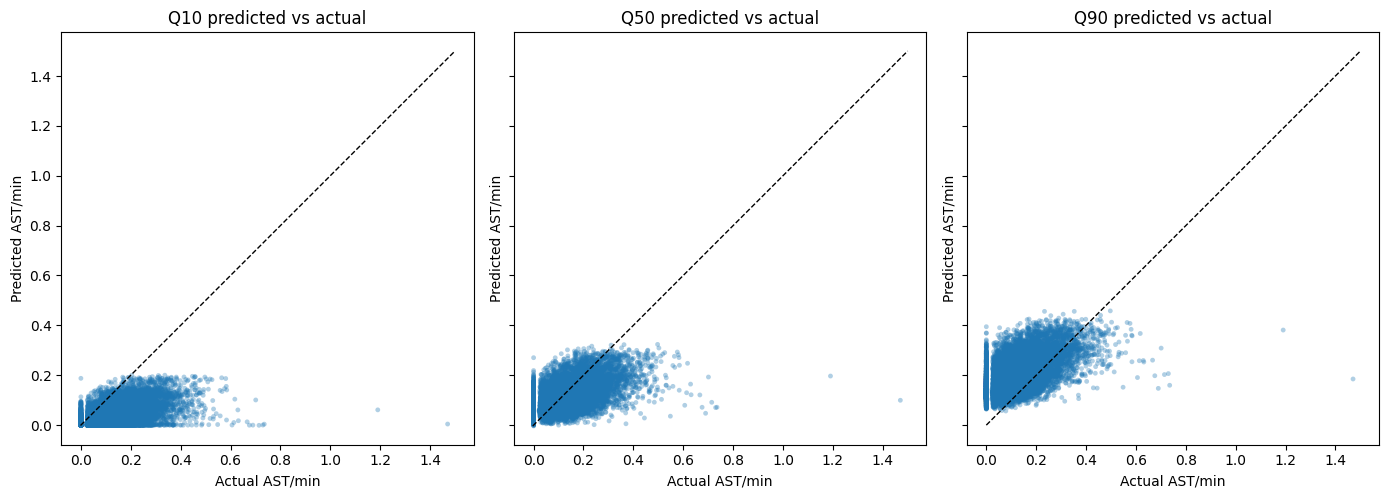

Q10 P(y ≤ pred): 0.13412205692866347
Q50 P(y ≤ pred): 0.5031041349420171
Q90 P(y ≤ pred): 0.8873726133302097
Coverage (10–90 interval): 75.33%


In [7]:
import matplotlib.pyplot as plt

y_true = y_val_ppm
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual AST/min")
    ax.set_ylabel("Predicted AST/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

In [8]:
# Use quantile regression to get a range instead of a single number
from sklearn.ensemble import GradientBoostingRegressor

lower = GradientBoostingRegressor(loss='quantile', alpha=0.1)
upper = GradientBoostingRegressor(loss='quantile', alpha=0.9)
mid   = GradientBoostingRegressor(loss='quantile', alpha=0.5)

lower.fit(X_train_ppm, y_train_ppm)
upper.fit(X_train_ppm, y_train_ppm)
mid.fit(X_train_ppm, y_train_ppm)

pred_low  = lower.predict(X_val_ppm)
pred_high = upper.predict(X_val_ppm)
pred_mid  = mid.predict(X_val_ppm)

# Coverage — what % of actuals fall within the interval?
coverage = ((y_val_ppm >= pred_low) & (y_val_ppm <= pred_high)).mean()
print(f"Coverage: {coverage:.2%}")  # want this close to 80%

Coverage: 89.73%


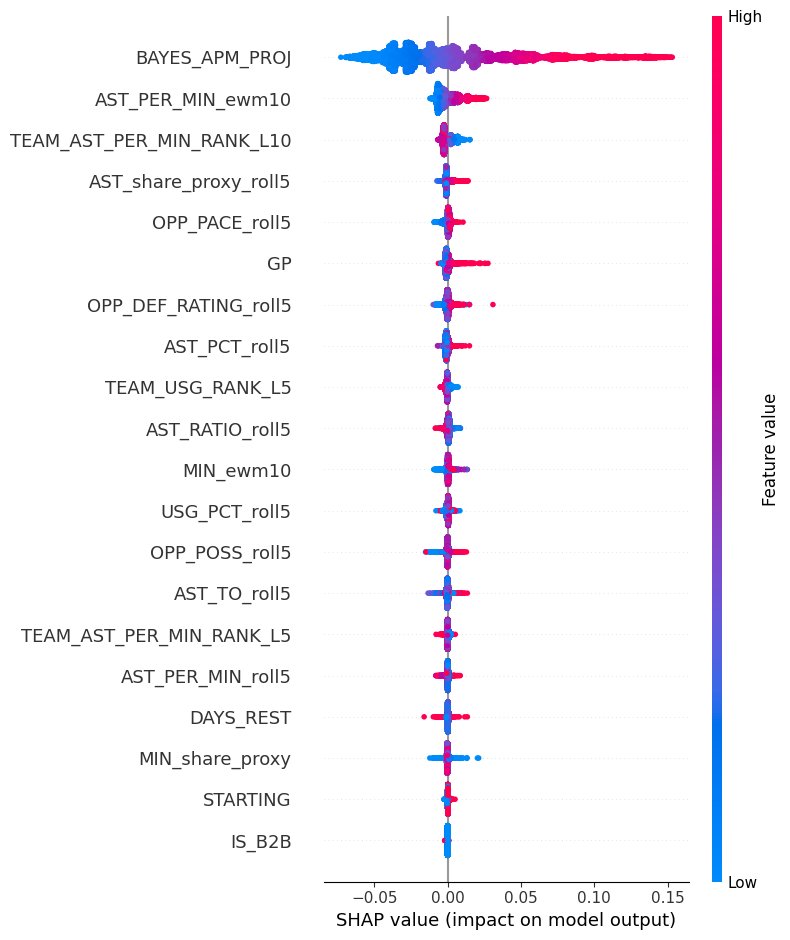

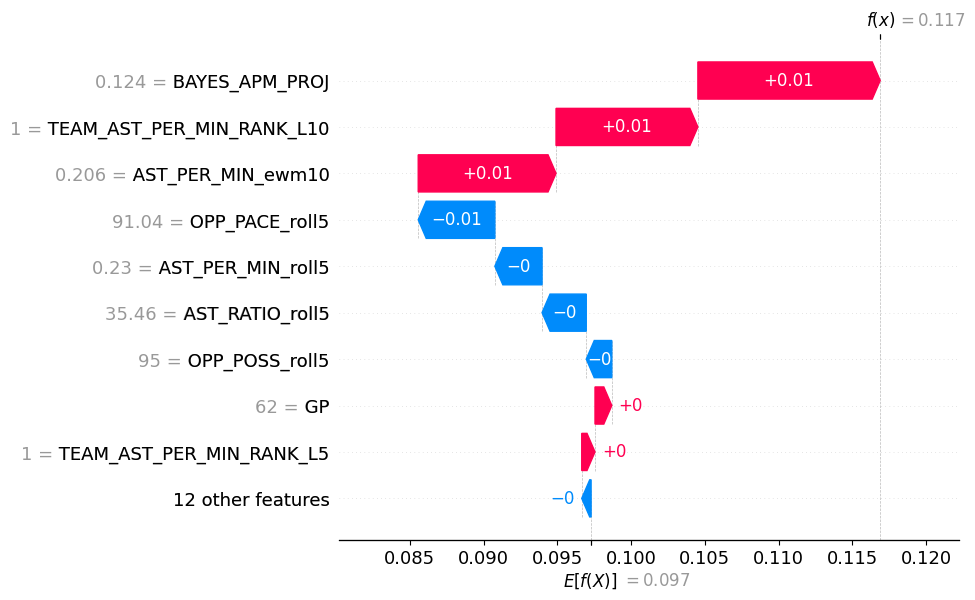

In [9]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_ppm)
shap.summary_plot(shap_values, X_val_ppm, feature_names=APM_FEATURES)
shap.plots.waterfall(shap_values[1154])

In [10]:
import joblib
from pathlib import Path

out_dir = Path("apm_quantile")  # or wherever you prefer
out_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "quantile_models": quantile_models,
    "feature_names": APM_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, out_dir / "apm_quantile_xgb.joblib")

['apm_quantile/apm_quantile_xgb.joblib']

In [11]:
from src.utils.scrap_starters import NBADailyLineups

scraper = NBADailyLineups("https://www.rotowire.com/basketball/nba-lineups.php")
scraper.getDict()  # Scrape the lineups
print("\nQuestionable Players:")
print(scraper.getQuestionablePlayers())
print("\nOut Players:")
print(scraper.getOutPlayers())
outPlayers = scraper.getOutPlayers()
scraper.updateTeamInfo()  # Update teamInfo.py


Questionable Players:
{'DEN': ['Bruce Brown']}

Out Players:
{'SAS': ['Emanuel Miller'], 'DEN': ['Spencer Jones', 'Peyton Watson', 'Zeke Nnaji'], 'WAS': ['Alex Sarr', 'Tristan Vukcevic', "D'Angelo Russell", 'Anthony Davis', 'Trae Young'], 'MIA': ['Terry Rozier', 'Tyler Herro', 'Norman Powell'], 'DET': ['Cade Cunningham', 'Isaiah Stewart'], 'PHI': ['Johni Broome', 'Joel Embiid']}
Successfully updated /Users/alexgonzalez/Documents/NBA-Prop-Predictor/src/utils/team_info.py
Updated 6 teams with confirmed lineups
Updated 1 teams with questionable players


In [12]:
date = pd.Timestamp.now().normalize()  # midnight today, local tz
current_date = date.strftime("%Y-%m-%d")

# target_date = pd.Timestamp("2026-03-26")
# hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_assists')]
names = lines_dfs['NAME'].unique()
names

array(['Jalen Brunson', 'Mikal Bridges', 'Derrick White',
       'Payton Pritchard', 'Ousmane Dieng', 'Ace Bailey', 'Reed Sheppard',
       'Cody Williams', 'Scottie Barnes', 'Brandon Ingram',
       'DeMar DeRozan', 'Derik Queen', 'Devin Vassell', 'Aaron Gordon'],
      dtype=object)

In [13]:
import joblib

min_bundle = joblib.load("src/models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

apm_bundle = joblib.load("src/models/apm_quantile_xgb.joblib")
apm_quantile_models = apm_bundle["quantile_models"]
apm_feature_names = apm_bundle["feature_names"]

## MIN + APM (ANALYSIS)

In [14]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        apm_feats = apm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(apm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(apm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(apm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(apm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_APM_Q10": p10,
            "PRED_APM_Q50": p50,
            "PRED_APM_Q90": p90,
            "PRED_AST_Q10": round(pts10, 2),
            "PRED_AST_Q50": round(pts50, 2),
            "PRED_AST_Q90": round(pts90, 2),
            "PRED_AST_RANGE_10_90": round(pts90 - pts10, 2),
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_APM_Q10": np.nan,
            "PRED_APM_Q50": np.nan,
            "PRED_APM_Q90": np.nan,
            "PRED_AST_Q10": np.nan,
            "PRED_AST_Q50": np.nan,
            "PRED_AST_Q90": np.nan,
            "PRED_AST_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_APM_Q10,PRED_APM_Q50,PRED_APM_Q90,PRED_AST_Q10,PRED_AST_Q50,PRED_AST_Q90,PRED_AST_RANGE_10_90
0,Jalen Brunson,30.662828,36.435535,39.150387,0.108115,0.203838,0.286830,3.32,7.43,11.23,7.91
1,Mikal Bridges,30.247663,35.988495,40.403244,0.119928,0.099047,0.183111,3.63,3.56,7.40,3.77
2,Derrick White,26.412291,33.251961,38.692032,0.141212,0.145427,0.241323,3.73,4.84,9.34,5.61
3,Payton Pritchard,21.385983,30.144594,35.646305,0.036351,0.142424,0.228421,0.78,4.29,8.14,7.36
4,Ousmane Dieng,20.996416,28.534967,34.705994,0.062665,0.138424,0.221789,1.32,3.95,7.70,6.38


In [19]:
def triangular_clip(row, q10, q50, q90, lo_scale=0.70, hi_scale=1.30, low=0.0, high=np.inf, n_sims=10_000):
    mode = float(row[q50])
    left = min(float(row[q10]) * lo_scale, mode)
    right = max(float(row[q90]) * hi_scale, mode)
    if not (np.isfinite(left) and np.isfinite(mode) and np.isfinite(right)):
        return np.clip(np.full(n_sims, np.nan), low, high)
    if left >= right:
        return np.clip(np.full(n_sims, mode), low, high)
    x = np.random.triangular(left, mode, right, size=n_sims)
    return np.clip(x, low, high)

def run_ast_simulation(row, n_sims=10_000):
    sim_min = triangular_clip(
        row,
        "PRED_MIN_Q10", "PRED_MIN_Q50", "PRED_MIN_Q90",
        lo_scale=0.75, hi_scale=1.25, low=0, high=48, n_sims=n_sims,
    )
    sim_apm = triangular_clip(
        row,
        "PRED_APM_Q10", "PRED_APM_Q50", "PRED_APM_Q90",
        lo_scale=0.70, hi_scale=1.30, low=0, high=np.inf, n_sims=n_sims,
    )
    return sim_min * sim_apm  # same index for both vectors → paired sims

# Build a lookup LINE by player name (adjust column names to your CSV)
line_by_name = lines_dfs.set_index("NAME")["LINE"].to_dict()

results = []
for _, row in preds_df.iterrows():
    name = row["PLAYER_NAME"]
    line = line_by_name.get(name)  # or map nameDict first
    if line is None or np.isnan(row.get("PRED_MIN_Q50", np.nan)):
        results.append({"PLAYER_NAME": name, "LINE": np.nan, "P_OVER": np.nan, "P_UNDER": np.nan})
        continue

    ast = run_ast_simulation(row)
    line = float(line)
    p_over = float(np.mean(ast > line))
    p_under = float(np.mean(ast < line))

    results.append({
    "PLAYER_NAME": name,
    "LINE": line,
    "PRED_MIN_Q50": round(row["PRED_MIN_Q50"], 2), 
    "PRED_AST_Q50": round(row["PRED_AST_Q50"], 2),
    "P_OVER": round(p_over, 2), 
    "P_UNDER": round(p_under, 2),
    'EDGE': row["PRED_AST_Q50"] - line,
    "EV": round(p_over * 20 - p_under * 10, 2)
    })

line_probs_df = pd.DataFrame(results)
line_probs_df.sort_values(by="EDGE", ascending=False)

,PLAYER_NAME,LINE,PRED_MIN_Q50,PRED_AST_Q50,P_OVER,P_UNDER,EDGE,EV
12,Devin Vassell,2.5,31.72,3.46,0.97,0.03,0.96,19.19
13,Aaron Gordon,2.5,29.85,3.36,0.97,0.03,0.86,19.05
10,DeMar DeRozan,4.5,35.57,5.22,0.73,0.27,0.72,12.04
9,Brandon Ingram,3.5,33.88,4.11,0.74,0.26,0.61,12.07
2,Derrick White,4.5,33.25,4.84,0.82,0.18,0.34,14.73
11,Derik Queen,3.5,28.13,3.59,0.60,0.40,0.09,8.10
1,Mikal Bridges,3.5,35.99,3.56,0.87,0.13,0.06,16.11
0,Jalen Brunson,7.5,36.44,7.43,0.51,0.49,-0.07,5.43
3,Payton Pritchard,4.5,30.14,4.29,0.50,0.50,-0.21,4.97
5,Ace Bailey,2.5,30.86,1.99,0.46,0.54,-0.51,3.88
